# RFM-сегментация и когортный retention (e-commerce)

Куда направить маркетинговый бюджет — кого удерживать VIP-программой, а кого
реактивировать акцией? И насколько вообще хорошо магазин удерживает клиентов месяц
к месяцу после первой покупки?

Датасет — интернет-магазин косметики за 2024–2025, 2 200 клиентов, ~6 100 позиций
заказов, 5 рынков (Россия, Казахстан, Беларусь, Мексика, США), 5 категорий, промо-периоды
и сезонность к ноябрю-декабрю. Данные смоделированы скриптом `generate_data.py` (seed
зафиксирован) — реальных клиентов компании тут нет, но структура и логика намеренно
похожи на настоящую розницу, чтобы результат был содержательным.

RFM (Recency / Frequency / Monetary, квартильный скоринг) — SQL-запрос поверх SQLite
(`sql/rfm_cohort.sql`). Когорты — % клиентов, вернувшихся за повторной покупкой в каждый
месяц после первой.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")

conn = sqlite3.connect(":memory:")
customers.to_sql("customers", conn, index=False)
orders.to_sql("orders", conn, index=False)

# Полный SQL — в sql/rfm_cohort.sql (то же самое, для читаемости отдельным файлом).
# Здесь выполняем те же view/запросы напрямую, чтобы не парсить .sql-файл построчно.
DDL = '''
DROP VIEW IF EXISTS order_totals;
CREATE VIEW order_totals AS
SELECT order_id, customer_id, order_date, SUM(revenue) AS order_revenue
FROM orders GROUP BY order_id, customer_id, order_date;

DROP VIEW IF EXISTS rfm_base;
CREATE VIEW rfm_base AS
WITH snapshot AS (SELECT MAX(order_date) AS snapshot_date FROM order_totals)
SELECT o.customer_id,
       CAST(julianday((SELECT snapshot_date FROM snapshot)) - julianday(MAX(o.order_date)) AS INTEGER) AS recency_days,
       COUNT(DISTINCT o.order_id) AS frequency,
       ROUND(SUM(o.order_revenue), 2) AS monetary
FROM order_totals o GROUP BY o.customer_id;

DROP VIEW IF EXISTS rfm_scored;
CREATE VIEW rfm_scored AS
WITH q AS (
    SELECT customer_id, recency_days, frequency, monetary,
           NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
           NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
           NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
    FROM rfm_base
)
SELECT *, (r_score + f_score + m_score) AS rfm_total,
    CASE
        WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions'
        WHEN r_score >= 3 AND f_score >= 3 THEN 'Loyal'
        WHEN r_score >= 3 AND f_score <= 2 THEN 'Promising'
        WHEN r_score <= 2 AND f_score >= 3 THEN 'At Risk'
        WHEN r_score <= 2 AND f_score <= 2 AND m_score <= 2 THEN 'Lost'
        ELSE 'Needs Attention'
    END AS segment
FROM q;

DROP VIEW IF EXISTS first_purchase;
CREATE VIEW first_purchase AS
SELECT customer_id, MIN(order_date) AS first_order_date FROM order_totals GROUP BY customer_id;

DROP VIEW IF EXISTS cohort_activity;
CREATE VIEW cohort_activity AS
SELECT fp.customer_id,
       strftime('%Y-%m', fp.first_order_date) AS cohort_month,
       strftime('%Y-%m', o.order_date) AS activity_month,
       (CAST(strftime('%Y', o.order_date) AS INTEGER) - CAST(strftime('%Y', fp.first_order_date) AS INTEGER)) * 12
           + (CAST(strftime('%m', o.order_date) AS INTEGER) - CAST(strftime('%m', fp.first_order_date) AS INTEGER)) AS month_index
FROM order_totals o JOIN first_purchase fp ON fp.customer_id = o.customer_id;
'''
conn.executescript(DDL)

QUERY_SEGMENTS = '''
SELECT segment, COUNT(*) AS customers, ROUND(SUM(monetary), 2) AS total_revenue,
       ROUND(100.0 * SUM(monetary) / (SELECT SUM(monetary) FROM rfm_scored), 1) AS revenue_share_pct,
       ROUND(AVG(frequency), 2) AS avg_orders
FROM rfm_scored GROUP BY segment ORDER BY total_revenue DESC;
'''
QUERY_COHORT = '''
SELECT cohort_month, month_index, COUNT(DISTINCT customer_id) AS active_customers
FROM cohort_activity GROUP BY cohort_month, month_index ORDER BY cohort_month, month_index;
'''

segment_summary = pd.read_sql(QUERY_SEGMENTS, conn)
cohort_raw = pd.read_sql(QUERY_COHORT, conn)
segment_summary

,segment,customers,total_revenue,revenue_share_pct,avg_orders
0,At Risk,362,55497.92,29.2,2.30
1,Loyal,371,52876.96,27.8,2.40
2,Champions,135,34377.69,18.1,3.56
3,Promising,362,20173.33,10.6,1.00
4,Lost,428,19315.56,10.2,1.00
5,Needs Attention,78,7639.65,4.0,1.00


## RFM: где выручка

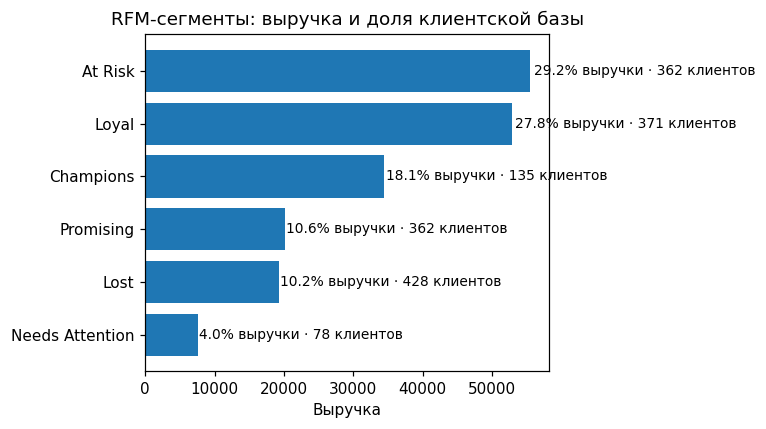

In [2]:
fig, ax = plt.subplots(figsize=(7,4))
order = segment_summary.sort_values('total_revenue', ascending=True)
bars = ax.barh(order['segment'], order['total_revenue'])
for bar, share, cust in zip(bars, order['revenue_share_pct'], order['customers']):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f"{share}% выручки · {cust} клиентов", va='center', fontsize=9)
ax.set_xlabel("Выручка")
ax.set_title("RFM-сегменты: выручка и доля клиентской базы")
plt.tight_layout()
plt.savefig("charts/rfm_segments.png", bbox_inches="tight")
plt.show()

## Когорты

In [3]:
cohort_pivot = cohort_raw.pivot(index='cohort_month', columns='month_index', values='active_customers')
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(1)
retention.iloc[:, :7]  # первые 6 месяцев жизни когорты

month_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2024-01,100.0,14.9,12.8,14.9,17.0,4.3,10.6
2024-02,100.0,10.9,7.3,9.1,3.6,1.8,1.8
2024-03,100.0,10.9,10.9,9.4,9.4,7.8,6.2
2024-04,100.0,12.9,6.5,6.5,6.5,NaN,8.1
2024-05,100.0,11.4,8.0,8.0,5.7,2.3,4.5
2024-06,100.0,10.3,7.7,11.5,6.4,11.5,10.3
2024-07,100.0,6.7,5.3,8.0,13.3,9.3,2.7
2024-08,100.0,9.6,5.8,15.4,7.7,5.8,9.6
2024-09,100.0,11.5,21.8,7.7,6.4,3.8,5.1


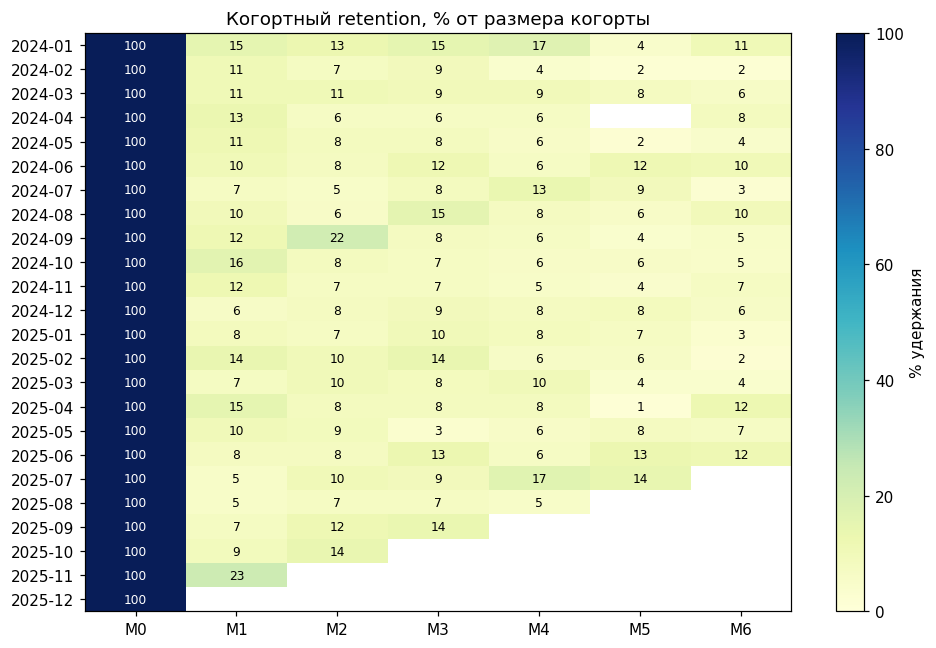

In [4]:
fig, ax = plt.subplots(figsize=(9,6))
data = retention.iloc[:, :7].values
im = ax.imshow(data, cmap='YlGnBu', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(data.shape[1]))
ax.set_xticklabels([f"M{i}" for i in range(data.shape[1])])
ax.set_yticks(range(len(retention.index)))
ax.set_yticklabels(retention.index)
ax.set_title("Когортный retention, % от размера когорты")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha='center', va='center',
                     color='white' if val > 50 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='% удержания')
plt.tight_layout()
plt.savefig("charts/cohort_heatmap.png", bbox_inches="tight")
plt.show()

In [5]:
order_totals_all = orders.groupby(["order_id","customer_id","order_date"], as_index=False)["revenue"].sum()
orders_per_customer = order_totals_all.groupby("customer_id").size()
print(f"Купили хотя бы раз: {len(orders_per_customer)} из {len(customers)} клиентов ({len(orders_per_customer)/len(customers):.1%})")
print(f"Из них только 1 заказ: {(orders_per_customer==1).mean():.1%}")
print(f"2+ заказа (вернулись хотя бы раз): {(orders_per_customer>=2).mean():.1%}")
print(f"5+ заказов ('ядро'): {(orders_per_customer>=5).mean():.1%}")

Купили хотя бы раз: 1736 из 2200 клиентов (78.9%)
Из них только 1 заказ: 55.6%
2+ заказа (вернулись хотя бы раз): 44.4%
5+ заказов ('ядро'): 3.2%


## Вывод

Из тех, кто купил хотя бы раз, 55.6% так и остаются one-time buyers — больше не
возвращаются. Только 44.4% делают вторую покупку, и лишь 3.2% дорастают до "ядра"
(5+ заказов). Это же видно и в когортной карте: помесячный retention держится в среднем
на ~8-12% и заметно шумит (когорты по ~90 человек — при таком размере это ожидаемо), но
порядок величины говорит об одном — теряем в основном на переходе от 1-й ко 2-й покупке,
а не из-за постепенного оттока лояльных.

При этом Loyal + Champions — это ~35% базы, но ~46% выручки. At Risk (раньше активные,
давно не покупали) — почти 29% выручки, которая просто "спит": вернуть их обычно дешевле,
чем привлечь новых.

Приоритет — не удержание "вообще", а конкретно конверсия в повторную покупку: welcome-
серия писем и скидка на 2-й заказ в первые недели, плюс отдельная реактивация на At Risk.